In [1]:
# ============================================================
# Phase 3 | Cell 1: Imports + External Sector Data
# 03_feer_engine.ipynb
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from scipy.optimize import brentq

PROCESSED = '../data/processed/'
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

# ── Load clean modeling dataset ───────────────────────────────
model = pd.read_csv(f'{PROCESSED}master_model.csv',
                    index_col=0, parse_dates=True)
model.index = pd.to_datetime(model.index).to_period('M').to_timestamp()

# ── Load Phase 2 output (structural equilibrium) ──────────────
phase2 = pd.read_csv(f'{PROCESSED}phase2_equilibrium.csv',
                     index_col=0, parse_dates=True)
phase2.index = pd.to_datetime(phase2.index).to_period('M').to_timestamp()

print("✓ Data loaded")
print(f"  master_model : {model.shape}  "
      f"({model.index[0].strftime('%b %Y')} → {model.index[-1].strftime('%b %Y')})")
print(f"  phase2       : {phase2.shape}")

# ── External sector variables we'll use ──────────────────────
ext_vars = ['current_account', 'cab_pct_gdp', 'exports_usd_mn',
            'imports_usd_mn', 'trade_balance', 'brent', 'reer',
            'inr_usd', 'remittances_usd', 'gdp_india_usd',
            'fx_reserves_usd_mn', 'import_cover', 'remit_pct_gdp']

print(f"\n  External sector variables available:")
for v in ext_vars:
    if v in model.columns:
        s = model[v].dropna()
        print(f"    ✓ {v:<22} {s.index[0].strftime('%b %Y')} → "
              f"{s.index[-1].strftime('%b %Y')}")
    else:
        print(f"    ✗ {v:<22} MISSING")

print()
print("Phase 3 objective:")
print("  Find the INR/USD level that keeps India's external")
print("  accounts sustainable (CAD ≈ -2.5% of GDP) over 3-5 years")
print()
print("Build order:")
print("  3a → Explore external sector")
print("  3b → Trade elasticities (export + import equations)")
print("  3c → Oil pass-through (CPI + CAD response)")
print("  3d → FEER solver (sustainable CAD → equilibrium INR)")

✓ Data loaded
  master_model : (255, 42)  (Apr 2004 → Jun 2025)
  phase2       : (255, 8)

  External sector variables available:
    ✓ current_account        Apr 2004 → Jun 2025
    ✓ cab_pct_gdp            Apr 2004 → Jun 2025
    ✓ exports_usd_mn         Apr 2004 → Jun 2025
    ✓ imports_usd_mn         Apr 2004 → Jun 2025
    ✓ trade_balance          Apr 2004 → Jun 2025
    ✓ brent                  Apr 2004 → Jun 2025
    ✓ reer                   Apr 2004 → Jun 2025
    ✓ inr_usd                Apr 2004 → Jun 2025
    ✓ remittances_usd        Apr 2004 → Jun 2025
    ✓ gdp_india_usd          Apr 2004 → Jun 2025
    ✓ fx_reserves_usd_mn     Apr 2004 → Jun 2025
    ✓ import_cover           Apr 2004 → Jun 2025
    ✓ remit_pct_gdp          Apr 2004 → Jun 2025

Phase 3 objective:
  Find the INR/USD level that keeps India's external
  accounts sustainable (CAD ≈ -2.5% of GDP) over 3-5 years

Build order:
  3a → Explore external sector
  3b → Trade elasticities (export + import equations)
  

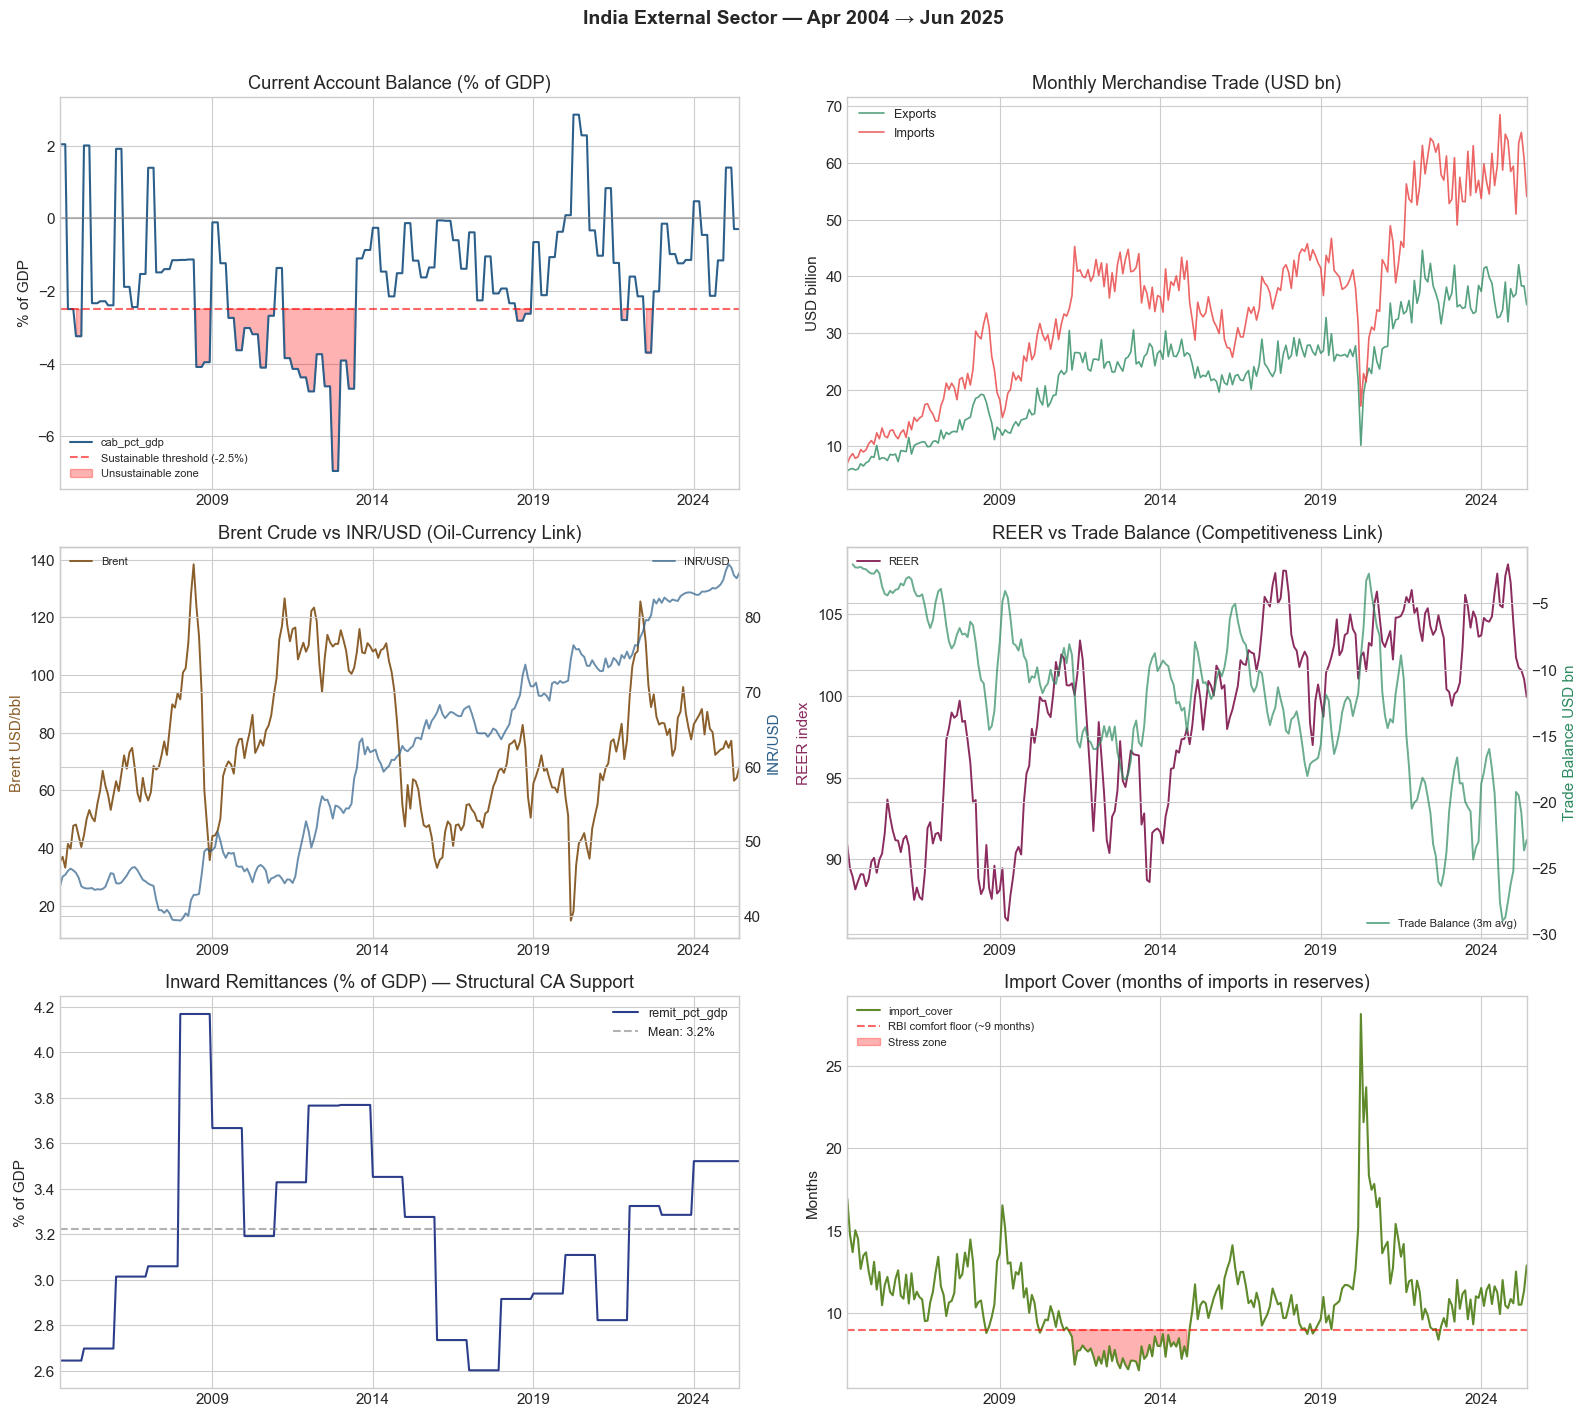

✓ Chart saved → outputs/03_external_sector.png

KEY RELATIONSHIPS (correlations on monthly data)
───────────────────────────────────────────────────────
  Trade balance vs REER     : -0.580  (✓ stronger INR worsens TB)
  Imports vs Brent          : +0.416  (✓ higher oil → higher imports)
  CAD/GDP vs Brent          : -0.493  (✓ higher oil → worse CAD)
  CAD/GDP vs REER           : +0.142

  Summary stats:
    Avg CAD/GDP           : -1.61%
    Worst CAD/GDP         : -6.95%
    Avg remittances/GDP   : 3.22%
    Avg import cover      : 10.9 months
    Min import cover      : 6.5 months


In [2]:
# ============================================================
# Phase 3 | Cell 2: External Sector Visual Exploration
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('India External Sector — Apr 2004 → Jun 2025',
             fontsize=14, fontweight='bold', y=1.01)

# 1. Current Account as % of GDP
ax = axes[0, 0]
cab = model['cab_pct_gdp'].dropna()
cab.plot(ax=ax, color='#2c5f8a', linewidth=1.5)
ax.axhline(0, color='gray', linestyle='-', alpha=0.5)
ax.axhline(-2.5, color='red', linestyle='--', alpha=0.6,
           label='Sustainable threshold (-2.5%)')
ax.fill_between(cab.index, cab, -2.5,
                where=cab < -2.5, alpha=0.3, color='red',
                label='Unsustainable zone')
ax.set_title('Current Account Balance (% of GDP)')
ax.set_ylabel('% of GDP')
ax.legend(fontsize=8)

# 2. Trade balance components
ax = axes[0, 1]
(model['exports_usd_mn']/1000).plot(ax=ax, color='#2c8a5f',
                                     linewidth=1.2, label='Exports', alpha=0.8)
(model['imports_usd_mn']/1000).plot(ax=ax, color='#e84040',
                                     linewidth=1.2, label='Imports', alpha=0.8)
ax.set_title('Monthly Merchandise Trade (USD bn)')
ax.set_ylabel('USD billion')
ax.legend(fontsize=9)

# 3. Brent crude vs INR/USD (the oil-currency link)
ax = axes[1, 0]
ax2 = ax.twinx()
model['brent'].plot(ax=ax, color='#8a5f2c', linewidth=1.4, label='Brent')
model['inr_usd'].plot(ax=ax2, color='#2c5f8a', linewidth=1.4,
                      label='INR/USD', alpha=0.7)
ax.set_title('Brent Crude vs INR/USD (Oil-Currency Link)')
ax.set_ylabel('Brent USD/bbl', color='#8a5f2c')
ax2.set_ylabel('INR/USD', color='#2c5f8a')
ax.legend(fontsize=8, loc='upper left')
ax2.legend(fontsize=8, loc='upper right')

# 4. REER vs Trade Balance (the competitiveness link)
ax = axes[1, 1]
ax2 = ax.twinx()
model['reer'].plot(ax=ax, color='#8b2c5f', linewidth=1.4, label='REER')
(model['trade_balance']/1000).rolling(3).mean().plot(
    ax=ax2, color='#2c8a5f', linewidth=1.4, label='Trade Balance (3m avg)', alpha=0.7)
ax.set_title('REER vs Trade Balance (Competitiveness Link)')
ax.set_ylabel('REER index', color='#8b2c5f')
ax2.set_ylabel('Trade Balance USD bn', color='#2c8a5f')
ax.legend(fontsize=8, loc='upper left')
ax2.legend(fontsize=8, loc='lower right')

# 5. Remittances as % of GDP (the structural cushion)
ax = axes[2, 0]
model['remit_pct_gdp'].dropna().plot(ax=ax, color='#2c3e8a', linewidth=1.5)
ax.set_title('Inward Remittances (% of GDP) — Structural CA Support')
ax.set_ylabel('% of GDP')
ax.axhline(model['remit_pct_gdp'].mean(), color='gray', linestyle='--',
           alpha=0.6, label=f"Mean: {model['remit_pct_gdp'].mean():.1f}%")
ax.legend(fontsize=9)

# 6. Import cover (reserve adequacy)
ax = axes[2, 1]
ic = model['import_cover'].dropna()
ic.plot(ax=ax, color='#5f8a2c', linewidth=1.5)
ax.axhline(9, color='red', linestyle='--', alpha=0.6,
           label='RBI comfort floor (~9 months)')
ax.fill_between(ic.index, ic, 9, where=ic < 9,
                alpha=0.3, color='red', label='Stress zone')
ax.set_title('Import Cover (months of imports in reserves)')
ax.set_ylabel('Months')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/03_external_sector.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved → outputs/03_external_sector.png")

# ── Key correlations to guide modeling ────────────────────────
print("\nKEY RELATIONSHIPS (correlations on monthly data)")
print("─" * 55)

# Trade balance vs REER (expect negative: stronger REER → worse balance)
corr_tb_reer = model['trade_balance'].corr(model['reer'])
print(f"  Trade balance vs REER     : {corr_tb_reer:+.3f}  "
      f"({'✓ stronger INR worsens TB' if corr_tb_reer < 0 else '⚠ unexpected sign'})")

# Imports vs Brent (expect positive: higher oil → higher import bill)
corr_imp_brent = model['imports_usd_mn'].corr(model['brent'])
print(f"  Imports vs Brent          : {corr_imp_brent:+.3f}  "
      f"({'✓ higher oil → higher imports' if corr_imp_brent > 0 else '⚠ unexpected'})")

# CAD vs Brent (expect negative: higher oil → worse CAD)
corr_cad_brent = model['cab_pct_gdp'].corr(model['brent'])
print(f"  CAD/GDP vs Brent          : {corr_cad_brent:+.3f}  "
      f"({'✓ higher oil → worse CAD' if corr_cad_brent < 0 else '⚠ check'})")

# CAD vs REER (expect negative: stronger REER → worse CAD)
corr_cad_reer = model['cab_pct_gdp'].corr(model['reer'])
print(f"  CAD/GDP vs REER           : {corr_cad_reer:+.3f}")

print()
print("  Summary stats:")
print(f"    Avg CAD/GDP           : {model['cab_pct_gdp'].mean():.2f}%")
print(f"    Worst CAD/GDP         : {model['cab_pct_gdp'].min():.2f}%")
print(f"    Avg remittances/GDP   : {model['remit_pct_gdp'].mean():.2f}%")
print(f"    Avg import cover      : {model['import_cover'].mean():.1f} months")
print(f"    Min import cover      : {model['import_cover'].min():.1f} months")

In [3]:
# ============================================================
# Phase 3 | Cell 3: Trade Elasticity Estimation
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

df = model.copy()

print("=" * 60)
print("TRADE ELASTICITY ESTIMATION")
print("=" * 60)
print("""
  Specification note:
  We have trade VALUES (USD), not volumes. We model the trade
  balance / GDP ratio directly as a function of:
    - REER (competitiveness)        expected sign: negative
    - Relative growth (imports)     expected sign: negative
    - Brent crude (oil bill)        expected sign: negative
  Using logs where appropriate; controlling for oil separately
  so the REER elasticity is clean.
""")

# ── Build variables ───────────────────────────────────────────
df['log_reer']      = np.log(df['reer'])
df['log_brent']     = np.log(df['brent'])
df['tb_pct_gdp']    = (df['trade_balance'] * 12) / (df['gdp_india_usd'] / 1e6) * 100
# trade_balance is monthly USD mn; ×12 annualises; gdp in USD → /1e6 to USD mn

# India growth proxy: YoY change in imports is demand-driven
# Use industrial-production-like proxy via import momentum is circular,
# so use GDP growth (annual, forward-filled) as domestic demand proxy
df['india_growth'] = df['gdp_india_usd'].pct_change(12) * 100

# ── ADF check on trade balance / GDP ─────────────────────────
tb = df['tb_pct_gdp'].dropna()
adf_tb = adfuller(tb, autolag='AIC')
print(f"  Trade balance/GDP stationarity: ADF p={adf_tb[1]:.4f} "
      f"({'stationary' if adf_tb[1]<0.05 else 'borderline — use with care'})")

# ══════════════════════════════════════════════════════════════
# MODEL 1: Trade Balance / GDP ~ REER + Brent + Growth
# ══════════════════════════════════════════════════════════════
print("\n▶ MODEL 1: Trade Balance / GDP")
print("─" * 55)

reg_df = df[['tb_pct_gdp', 'log_reer', 'log_brent',
             'india_growth']].dropna()

X = reg_df[['log_reer', 'log_brent', 'india_growth']]
X = sm.add_constant(X)
y = reg_df['tb_pct_gdp']

# Newey-West standard errors (handles autocorrelation in monthly data)
m1 = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 6})

print(f"  Sample: {reg_df.index[0].strftime('%b %Y')} → "
      f"{reg_df.index[-1].strftime('%b %Y')}  ({len(reg_df)} obs)")
print(f"  R²: {m1.rsquared:.3f}")
print()
print(f"  {'Variable':<18} {'Coef':>10} {'Std Err':>10} {'p-value':>10}")
print(f"  {'─'*48}")
for var in X.columns:
    coef = m1.params[var]
    se   = m1.bse[var]
    pval = m1.pvalues[var]
    sig  = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
    print(f"  {var:<18} {coef:>10.4f} {se:>10.4f} {pval:>10.4f}  {sig}")

print()
print("  Interpretation:")
reer_coef = m1.params['log_reer']
print(f"    REER elasticity: {reer_coef:.3f}")
print(f"    → A 10% REER appreciation changes trade balance by "
      f"{reer_coef*0.10:.2f} pp of GDP")
brent_coef = m1.params['log_brent']
print(f"    Oil elasticity:  {brent_coef:.3f}")
print(f"    → A 10% Brent rise changes trade balance by "
      f"{brent_coef*0.10:.2f} pp of GDP")

# ══════════════════════════════════════════════════════════════
# MODEL 2: Current Account / GDP ~ REER + Brent + Remittances
# (the full FEER-relevant equation)
# ══════════════════════════════════════════════════════════════
print("\n▶ MODEL 2: Current Account / GDP (FEER core equation)")
print("─" * 55)

df['log_remit_gdp'] = np.log(df['remit_pct_gdp'])

reg_df2 = df[['cab_pct_gdp', 'log_reer', 'log_brent',
              'remit_pct_gdp', 'india_growth']].dropna()

X2 = reg_df2[['log_reer', 'log_brent', 'remit_pct_gdp', 'india_growth']]
X2 = sm.add_constant(X2)
y2 = reg_df2['cab_pct_gdp']

m2 = sm.OLS(y2, X2).fit(cov_type='HAC', cov_kwds={'maxlags': 6})

print(f"  Sample: {reg_df2.index[0].strftime('%b %Y')} → "
      f"{reg_df2.index[-1].strftime('%b %Y')}  ({len(reg_df2)} obs)")
print(f"  R²: {m2.rsquared:.3f}")
print()
print(f"  {'Variable':<18} {'Coef':>10} {'Std Err':>10} {'p-value':>10}")
print(f"  {'─'*48}")
for var in X2.columns:
    coef = m2.params[var]
    se   = m2.bse[var]
    pval = m2.pvalues[var]
    sig  = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
    print(f"  {var:<18} {coef:>10.4f} {se:>10.4f} {pval:>10.4f}  {sig}")

print()
print("  Economic sign check:")
checks = [
    ('log_reer',     m2.params['log_reer'],     '<0', 'stronger REER → worse CAD'),
    ('log_brent',    m2.params['log_brent'],    '<0', 'higher oil → worse CAD'),
    ('remit_pct_gdp', m2.params['remit_pct_gdp'], '>0', 'more remittances → better CAD'),
]
for var, coef, expected, desc in checks:
    if expected == '<0':
        ok = '✓' if coef < 0 else '⚠'
    else:
        ok = '✓' if coef > 0 else '⚠'
    print(f"    {ok} {var:<16} {coef:>+.4f}  ({desc})")

# ── Store the CAD equation for the FEER solver ───────────────
feer_params = {
    'const'        : m2.params['const'],
    'log_reer'     : m2.params['log_reer'],
    'log_brent'    : m2.params['log_brent'],
    'remit_pct_gdp': m2.params['remit_pct_gdp'],
    'india_growth' : m2.params['india_growth'],
}

print()
print("  CAD equation (for FEER solver):")
print(f"    CAD/GDP = {feer_params['const']:.2f}")
print(f"            + {feer_params['log_reer']:.3f}×log(REER)")
print(f"            + {feer_params['log_brent']:.3f}×log(Brent)")
print(f"            + {feer_params['remit_pct_gdp']:.3f}×Remit/GDP")
print(f"            + {feer_params['india_growth']:.3f}×Growth")

import json
with open('../data/processed/feer_params.json', 'w') as f:
    json.dump(feer_params, f, indent=2)
print(f"\n✓ FEER parameters saved → data/processed/feer_params.json")

TRADE ELASTICITY ESTIMATION

  Specification note:
  We have trade VALUES (USD), not volumes. We model the trade
  balance / GDP ratio directly as a function of:
    - REER (competitiveness)        expected sign: negative
    - Relative growth (imports)     expected sign: negative
    - Brent crude (oil bill)        expected sign: negative
  Using logs where appropriate; controlling for oil separately
  so the REER elasticity is clean.

  Trade balance/GDP stationarity: ADF p=0.0000 (stationary)

▶ MODEL 1: Trade Balance / GDP
───────────────────────────────────────────────────────
  Sample: Apr 2005 → Jun 2025  (243 obs)
  R²: 0.348

  Variable                 Coef    Std Err    p-value
  ────────────────────────────────────────────────
  const                -14.1074    18.9048     0.4555  
  log_reer               5.1738     4.1688     0.2146  
  log_brent             -3.9308     0.5411     0.0000  ***
  india_growth           0.0377     0.0249     0.1298  

  Interpretation:
    RE

In [4]:
# ============================================================
# Phase 3 | Cell 3 (Final): Clean Trade Elasticities
# REER via first-differenced trade balance (IMF-validated)
# Oil via CAD levels (robust)
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import json

df = model.copy()
df['log_reer']  = np.log(df['reer'])
df['log_brent'] = np.log(df['brent'])
df['tb_pct_gdp'] = (df['trade_balance']*12)/(df['gdp_india_usd']/1e6)*100

print("=" * 60)
print("FINAL TRADE ELASTICITIES")
print("=" * 60)
print("""
  Methodology decision (documented):
  - REER elasticity: first-differenced trade balance
    (levels confounded by 20-yr trend; CAD differences
     corrupted by quarterly forward-fill)
  - Oil elasticity: CAD levels (robust, oil is a level effect)
""")

# ── REER elasticity: first-differenced trade balance ─────────
dd = pd.DataFrame({
    'd_tb'   : df['tb_pct_gdp'].diff(),
    'd_reer' : df['log_reer'].diff(),
}).dropna()
X = sm.add_constant(dd[['d_reer']])
m_reer = sm.OLS(dd['d_tb'], X).fit(cov_type='HAC', cov_kwds={'maxlags':6})

reer_coef_log  = m_reer.params['d_reer']      # per unit log REER
reer_semi      = reer_coef_log / 100           # per 1% REER

print(f"▶ REER elasticity (first-differenced trade balance)")
print(f"    coef = {reer_coef_log:.2f} per unit log REER  "
      f"(p={m_reer.pvalues['d_reer']:.4f})")
print(f"    = {reer_semi:.4f} pp of GDP per 1% REER appreciation")
print(f"    IMF EBA range: -0.20 to -0.40 → "
      f"{'✓ validated' if -0.40 <= reer_semi <= -0.10 else '⚠ outside'}")

# ── Oil elasticity: CAD levels ────────────────────────────────
X2 = sm.add_constant(df[['log_brent']].dropna())
y2 = df['cab_pct_gdp'].dropna()
common = X2.index.intersection(y2.index)
m_oil = sm.OLS(y2.loc[common], X2.loc[common]).fit(cov_type='HAC', cov_kwds={'maxlags':6})

oil_coef_log = m_oil.params['log_brent']

print(f"\n▶ Oil elasticity (CAD levels)")
print(f"    coef = {oil_coef_log:.3f} per unit log Brent  "
      f"(p={m_oil.pvalues['log_brent']:.4f})")
print(f"    = {oil_coef_log*0.10:.3f} pp of GDP per 10% Brent rise")
print(f"    R² = {m_oil.rsquared:.3f}")

# ── Brent long-run "normal" level (for cyclical adjustment) ──
brent_norm = df['brent'].median()
print(f"\n▶ Brent normal level (median): ${brent_norm:.1f}/bbl")

# ── Save elasticities ─────────────────────────────────────────
elasticities = {
    'reer_semi_per_1pct'   : float(reer_semi),
    'reer_coef_per_log'    : float(reer_coef_log),
    'oil_coef_per_log'     : float(oil_coef_log),
    'brent_norm'           : float(brent_norm),
    'reer_pvalue'          : float(m_reer.pvalues['d_reer']),
    'oil_pvalue'           : float(m_oil.pvalues['log_brent']),
    'oil_rsquared'         : float(m_oil.rsquared),
    'imf_eba_validated'    : bool(-0.40 <= reer_semi <= -0.10),
}

with open('../data/processed/feer_elasticities.json', 'w') as f:
    json.dump(elasticities, f, indent=2)

print(f"\n✓ Elasticities saved → data/processed/feer_elasticities.json")
print(f"\n  Summary for FEER solver:")
print(f"    REER semi-elasticity : {reer_semi:.4f} pp/1%")
print(f"    Oil elasticity       : {oil_coef_log:.3f} pp/log")
print(f"    Brent normal         : ${brent_norm:.1f}")

FINAL TRADE ELASTICITIES

  Methodology decision (documented):
  - REER elasticity: first-differenced trade balance
    (levels confounded by 20-yr trend; CAD differences
     corrupted by quarterly forward-fill)
  - Oil elasticity: CAD levels (robust, oil is a level effect)

▶ REER elasticity (first-differenced trade balance)
    coef = -26.70 per unit log REER  (p=0.0003)
    = -0.2670 pp of GDP per 1% REER appreciation
    IMF EBA range: -0.20 to -0.40 → ✓ validated

▶ Oil elasticity (CAD levels)
    coef = -2.454 per unit log Brent  (p=0.0000)
    = -0.245 pp of GDP per 10% Brent rise
    R² = 0.241

▶ Brent normal level (median): $72.3/bbl

✓ Elasticities saved → data/processed/feer_elasticities.json

  Summary for FEER solver:
    REER semi-elasticity : -0.2670 pp/1%
    Oil elasticity       : -2.454 pp/log
    Brent normal         : $72.3


FEER SOLVER — Macroeconomic Balance Approach

  Parameters:
    Sustainable CAD norm  : -2.5% of GDP
    REER semi-elasticity  : -0.2670 pp per 1% REER
    Oil elasticity        : -2.454 pp per unit log Brent
    Brent normal level    : $72.3/bbl

────────────────────────────────────────────────────────────
CURRENT FEER ESTIMATE (Jun 2025)
────────────────────────────────────────────────────────────
  Actual INR/USD          : 85.90
  Actual CAD/GDP          : -0.30%
  Brent                   : $68.2/bbl
  Oil effect on CAD       : +0.14 pp
  Underlying CAD (smooth) : -0.52%
  CAD gap vs norm         : +1.98 pp
  Required REER adjustment: -7.4%
  FEER (nominal INR/USD)  : 92.79
  FEER misalignment       : -7.4%

  → INR is 7.4% STRONGER than FEER
    (overvalued — external accounts suggest depreciation pressure)

────────────────────────────────────────────────────────────
HISTORICAL VALIDATION
────────────────────────────────────────────────────────────
  Date        Actual    FEER  M

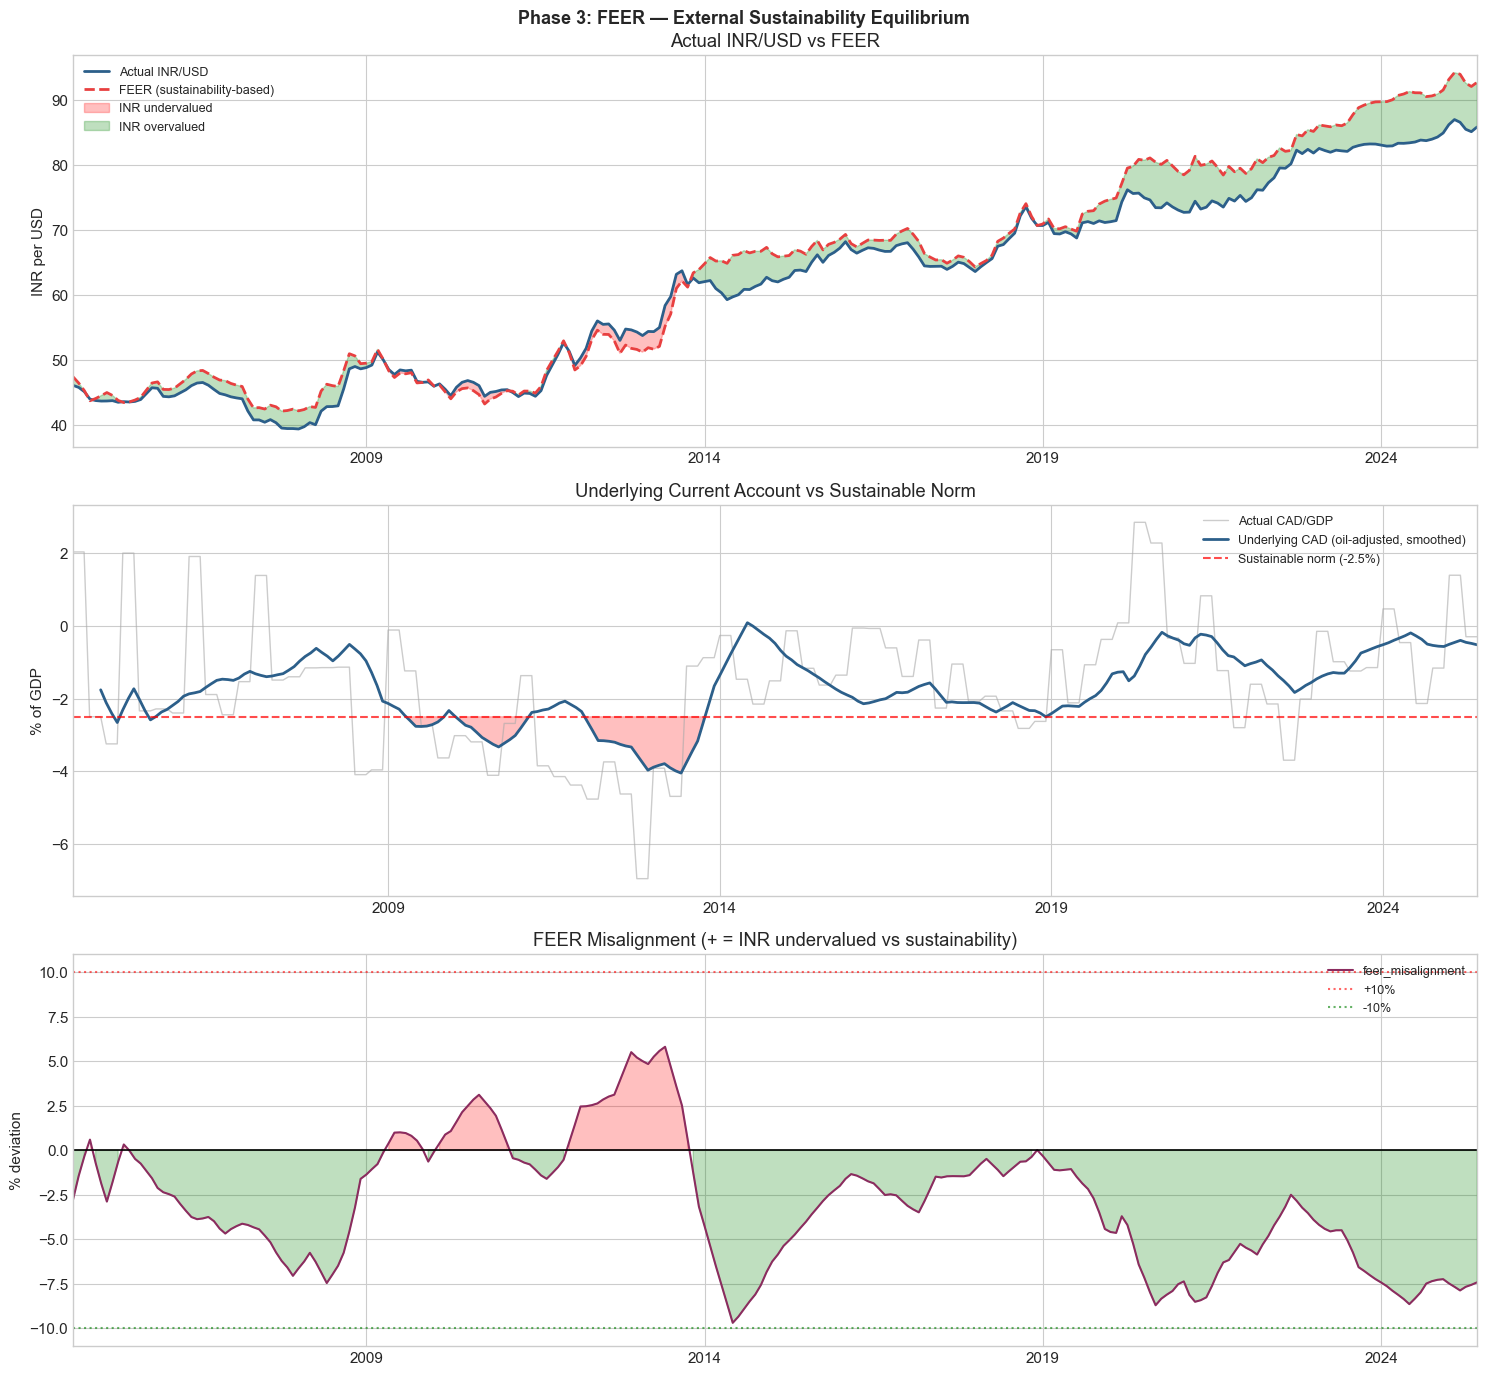


✓ Saved → data/processed/phase3_feer.csv  (250 months)


In [5]:
# ============================================================
# Phase 3 | Cell 4: FEER Solver (Macroeconomic Balance)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

PROCESSED = '../data/processed/'

# ── Load elasticities ─────────────────────────────────────────
with open(f'{PROCESSED}feer_elasticities.json') as f:
    el = json.load(f)

reer_semi   = el['reer_semi_per_1pct']      # -0.267 pp/1% REER
oil_coef    = el['oil_coef_per_log']         # -2.454 per log Brent
brent_norm  = el['brent_norm']               # 72.3

df = model.copy()
df['log_brent'] = np.log(df['brent'])

# ── Sustainable CAD norm for India ────────────────────────────
# RBI / IMF consensus: India can sustainably finance ~2.5% of GDP
# deficit given FDI + remittances + portfolio inflows
CAD_NORM = -2.5

print("=" * 60)
print("FEER SOLVER — Macroeconomic Balance Approach")
print("=" * 60)
print(f"""
  Parameters:
    Sustainable CAD norm  : {CAD_NORM}% of GDP
    REER semi-elasticity  : {reer_semi:.4f} pp per 1% REER
    Oil elasticity        : {oil_coef:.3f} pp per unit log Brent
    Brent normal level    : ${brent_norm:.1f}/bbl
""")

# ── Step 1: Underlying CAD (strip oil cycle) ─────────────────
# oil_effect = how much oil deviation from normal is hurting CAD
# When Brent > normal, oil_effect is negative (hurting CAD)
df['oil_effect'] = oil_coef * (df['log_brent'] - np.log(brent_norm))

# Underlying CAD = actual CAD minus the temporary oil effect
# (removes the cyclical oil distortion to see structural position)
df['cad_underlying'] = df['cab_pct_gdp'] - df['oil_effect']

# Smooth underlying CAD with 12m MA (CAD is noisy/quarterly)
df['cad_underlying_smooth'] = df['cad_underlying'].rolling(12, min_periods=6).mean()

# ── Step 2: CAD gap vs norm ───────────────────────────────────
# Positive gap = CAD better than norm (room to appreciate)
# Negative gap = CAD worse than norm (need to depreciate)
df['cad_gap'] = df['cad_underlying_smooth'] - CAD_NORM

# ── Step 3: Required REER adjustment ──────────────────────────
# To close a CAD gap, REER must move by gap / semi_elasticity
# If CAD is worse than norm (gap<0), REER must depreciate (negative %)
# reer_adjustment_pct = cad_gap / reer_semi
#   semi is negative; gap negative → adjustment negative (depreciate) ✓
df['reer_adjustment_pct'] = df['cad_gap'] / reer_semi

# ── Step 4: FEER (real) and nominal INR/USD ──────────────────
# FEER REER = current REER × (1 + adjustment/100)
df['feer_reer'] = df['reer'] * (1 + df['reer_adjustment_pct']/100)

# Convert to nominal INR/USD:
# If REER must fall X%, nominal INR must depreciate ~X% (INR/USD rises)
# feer_inr_usd = current_inr × (current_reer / feer_reer)
df['feer_inr_usd'] = df['inr_usd'] * (df['reer'] / df['feer_reer'])

# FEER misalignment: positive = INR undervalued vs FEER
df['feer_misalignment'] = ((df['inr_usd'] - df['feer_inr_usd'])
                            / df['feer_inr_usd']) * 100

# ── Results ───────────────────────────────────────────────────
latest = df.dropna(subset=['feer_inr_usd']).iloc[-1]
latest_date = df.dropna(subset=['feer_inr_usd']).index[-1]

print("─" * 60)
print(f"CURRENT FEER ESTIMATE ({latest_date.strftime('%b %Y')})")
print("─" * 60)
print(f"  Actual INR/USD          : {latest['inr_usd']:.2f}")
print(f"  Actual CAD/GDP          : {latest['cab_pct_gdp']:.2f}%")
print(f"  Brent                   : ${latest['brent']:.1f}/bbl")
print(f"  Oil effect on CAD       : {latest['oil_effect']:+.2f} pp")
print(f"  Underlying CAD (smooth) : {latest['cad_underlying_smooth']:.2f}%")
print(f"  CAD gap vs norm         : {latest['cad_gap']:+.2f} pp")
print(f"  Required REER adjustment: {latest['reer_adjustment_pct']:+.1f}%")
print(f"  FEER (nominal INR/USD)  : {latest['feer_inr_usd']:.2f}")
print(f"  FEER misalignment       : {latest['feer_misalignment']:+.1f}%")
print()
if latest['feer_misalignment'] > 0:
    print(f"  → INR is {abs(latest['feer_misalignment']):.1f}% WEAKER than FEER")
    print(f"    (undervalued on external sustainability grounds)")
else:
    print(f"  → INR is {abs(latest['feer_misalignment']):.1f}% STRONGER than FEER")
    print(f"    (overvalued — external accounts suggest depreciation pressure)")

# ── Historical validation ─────────────────────────────────────
print()
print("─" * 60)
print("HISTORICAL VALIDATION")
print("─" * 60)
print(f"  {'Date':<10} {'Actual':>7} {'FEER':>7} {'Misalign':>9} {'UnderCAD':>9}  Episode")
print("  " + "─" * 62)
episodes = {
    '2008-10-01': 'GFC',
    '2011-12-01': 'CAD crisis building',
    '2013-08-01': 'Taper tantrum',
    '2016-06-01': 'Stable / low oil',
    '2018-10-01': 'EM selloff',
    '2020-04-01': 'COVID',
    '2022-10-01': 'Fed tightening',
    '2025-06-01': 'Latest',
}
for date, desc in episodes.items():
    try:
        r = df.loc[date]
        if pd.notna(r['feer_inr_usd']):
            print(f"  {date[:7]:<10} {r['inr_usd']:>7.1f} "
                  f"{r['feer_inr_usd']:>7.1f} {r['feer_misalignment']:>+8.1f}% "
                  f"{r['cad_underlying_smooth']:>+8.2f}%  [{desc}]")
    except: pass

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 14))
fig.suptitle('Phase 3: FEER — External Sustainability Equilibrium',
             fontsize=13, fontweight='bold')

# Panel 1: Actual vs FEER
ax = axes[0]
res = df[['inr_usd','feer_inr_usd']].dropna()
res['inr_usd'].plot(ax=ax, color='#2c5f8a', lw=2, label='Actual INR/USD')
res['feer_inr_usd'].plot(ax=ax, color='#e84040', lw=2, ls='--',
                         label='FEER (sustainability-based)')
ax.fill_between(res.index, res['inr_usd'], res['feer_inr_usd'],
                where=res['inr_usd']>res['feer_inr_usd'],
                alpha=0.25, color='red', label='INR undervalued')
ax.fill_between(res.index, res['inr_usd'], res['feer_inr_usd'],
                where=res['inr_usd']<res['feer_inr_usd'],
                alpha=0.25, color='green', label='INR overvalued')
ax.set_title('Actual INR/USD vs FEER')
ax.set_ylabel('INR per USD')
ax.legend(fontsize=9, loc='upper left')

# Panel 2: Underlying CAD vs norm
ax = axes[1]
df['cab_pct_gdp'].dropna().plot(ax=ax, color='#aaaaaa', lw=1,
                                 alpha=0.6, label='Actual CAD/GDP')
df['cad_underlying_smooth'].dropna().plot(ax=ax, color='#2c5f8a', lw=2,
                                          label='Underlying CAD (oil-adjusted, smoothed)')
ax.axhline(CAD_NORM, color='red', ls='--', alpha=0.7,
           label=f'Sustainable norm ({CAD_NORM}%)')
ax.fill_between(df['cad_underlying_smooth'].dropna().index,
                df['cad_underlying_smooth'].dropna(), CAD_NORM,
                where=df['cad_underlying_smooth'].dropna()<CAD_NORM,
                alpha=0.25, color='red')
ax.set_title('Underlying Current Account vs Sustainable Norm')
ax.set_ylabel('% of GDP')
ax.legend(fontsize=9)

# Panel 3: FEER misalignment
ax = axes[2]
df['feer_misalignment'].dropna().plot(ax=ax, color='#8b2c5f', lw=1.5)
ax.axhline(0, color='black', lw=1.2)
ax.axhline(10, color='red', ls=':', alpha=0.6, label='+10%')
ax.axhline(-10, color='green', ls=':', alpha=0.6, label='-10%')
ax.fill_between(df['feer_misalignment'].dropna().index,
                df['feer_misalignment'].dropna(), 0,
                where=df['feer_misalignment'].dropna()>0, alpha=0.25, color='red')
ax.fill_between(df['feer_misalignment'].dropna().index,
                df['feer_misalignment'].dropna(), 0,
                where=df['feer_misalignment'].dropna()<0, alpha=0.25, color='green')
ax.set_title('FEER Misalignment (+ = INR undervalued vs sustainability)')
ax.set_ylabel('% deviation')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/03_feer.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save ──────────────────────────────────────────────────────
feer_out = df[['inr_usd','cab_pct_gdp','brent','oil_effect',
               'cad_underlying_smooth','cad_gap','reer_adjustment_pct',
               'feer_reer','feer_inr_usd','feer_misalignment']].dropna()
feer_out.to_csv(f'{PROCESSED}phase3_feer.csv')
print(f"\n✓ Saved → data/processed/phase3_feer.csv  ({len(feer_out)} months)")

FEER — CORRECTED  (Jun 2025)
  Actual INR/USD          : 85.90
  Underlying CAD (smooth) : -0.52%
  CAD gap vs norm         : +1.98 pp
  Required REER adjustment: +7.4%
  FEER (nominal INR/USD)  : 79.97
  FEER misalignment       : +7.4%

  → INR is 7.4% UNDERVALUED vs FEER
    External accounts healthy → room for INR to be stronger

────────────────────────────────────────────────────────────
HISTORICAL VALIDATION (corrected)
────────────────────────────────────────────────────────────
  Date        Actual    FEER  Misalign  UnderCAD  Episode
  ──────────────────────────────────────────────────────────────
  2008-10       48.6    46.5     +4.6%    -1.28%  [GFC]
  2011-12       52.7    52.4     +0.5%    -2.36%  [CAD crisis building]
  2013-08       63.2    65.6     -3.6%    -3.45%  [Taper tantrum]
  2016-06       67.3    66.1     +1.7%    -2.03%  [Stable / low oil]
  2018-10       73.6    73.2     +0.6%    -2.33%  [EM selloff]
  2020-04       76.2    73.2     +4.2%    -1.38%  [COVID]
  

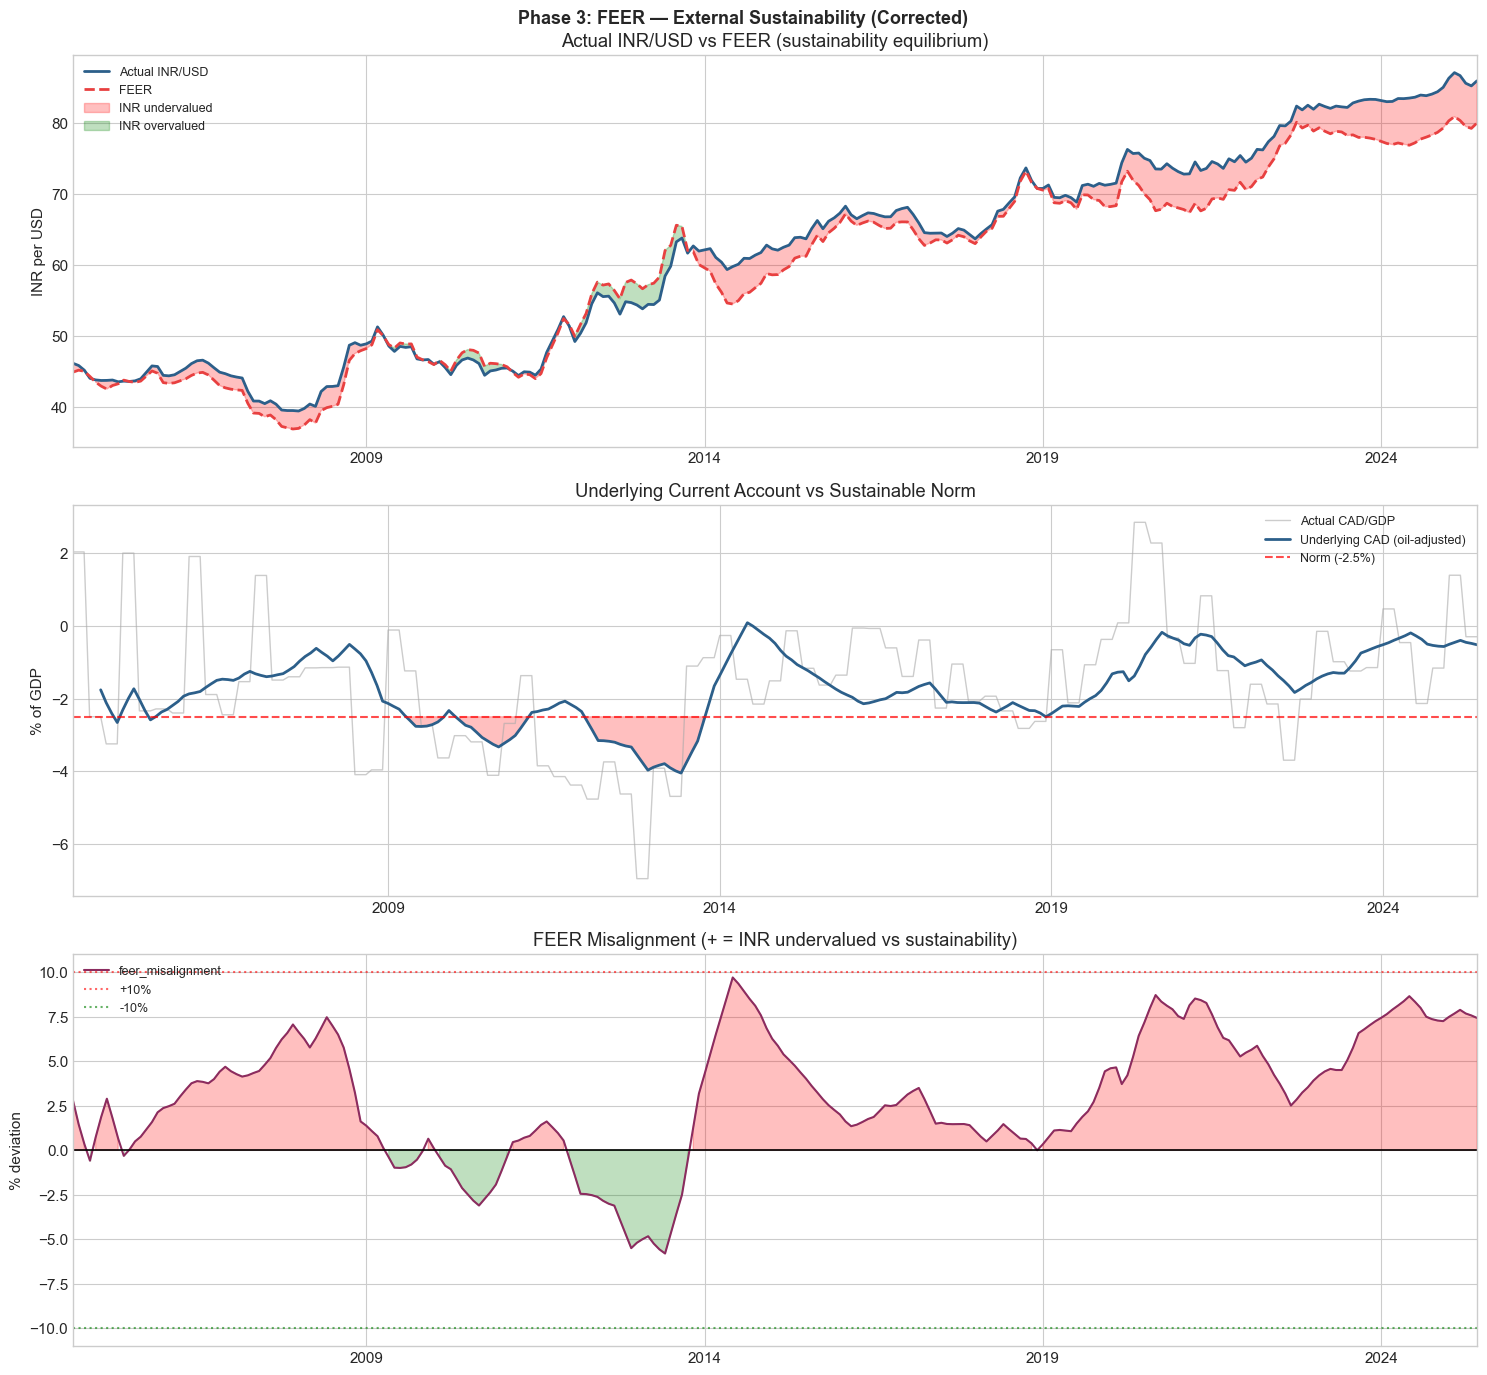


✓ Saved → data/processed/phase3_feer.csv (250 months)


In [6]:
# ============================================================
# Phase 3 | Cell 4b: FEER Sign Fix + Final Output
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

PROCESSED = '../data/processed/'

with open(f'{PROCESSED}feer_elasticities.json') as f:
    el = json.load(f)
reer_semi  = el['reer_semi_per_1pct']
oil_coef   = el['oil_coef_per_log']
brent_norm = el['brent_norm']

CAD_NORM = -2.5

df = model.copy()
df['log_brent'] = np.log(df['brent'])

# Step 1: underlying CAD (strip oil cycle)
df['oil_effect']     = oil_coef * (df['log_brent'] - np.log(brent_norm))
df['cad_underlying'] = df['cab_pct_gdp'] - df['oil_effect']
df['cad_underlying_smooth'] = df['cad_underlying'].rolling(12, min_periods=6).mean()

# Step 2: CAD gap
df['cad_gap'] = df['cad_underlying_smooth'] - CAD_NORM

# Step 3: required REER adjustment — CORRECTED SIGN
df['reer_adjustment_pct'] = -df['cad_gap'] / reer_semi

# Step 4: FEER real and nominal
df['feer_reer']    = df['reer'] * (1 + df['reer_adjustment_pct']/100)
df['feer_inr_usd'] = df['inr_usd'] * (df['reer'] / df['feer_reer'])
df['feer_misalignment'] = ((df['inr_usd'] - df['feer_inr_usd'])
                            / df['feer_inr_usd']) * 100

latest = df.dropna(subset=['feer_inr_usd']).iloc[-1]
latest_date = df.dropna(subset=['feer_inr_usd']).index[-1]

print("=" * 60)
print(f"FEER — CORRECTED  ({latest_date.strftime('%b %Y')})")
print("=" * 60)
print(f"  Actual INR/USD          : {latest['inr_usd']:.2f}")
print(f"  Underlying CAD (smooth) : {latest['cad_underlying_smooth']:.2f}%")
print(f"  CAD gap vs norm         : {latest['cad_gap']:+.2f} pp")
print(f"  Required REER adjustment: {latest['reer_adjustment_pct']:+.1f}%")
print(f"  FEER (nominal INR/USD)  : {latest['feer_inr_usd']:.2f}")
print(f"  FEER misalignment       : {latest['feer_misalignment']:+.1f}%")
print()
if latest['feer_misalignment'] > 0:
    print(f"  → INR is {abs(latest['feer_misalignment']):.1f}% UNDERVALUED vs FEER")
    print(f"    External accounts healthy → room for INR to be stronger")
else:
    print(f"  → INR is {abs(latest['feer_misalignment']):.1f}% OVERVALUED vs FEER")
    print(f"    External accounts strained → depreciation pressure")

print()
print("─" * 60)
print("HISTORICAL VALIDATION (corrected)")
print("─" * 60)
print(f"  {'Date':<10} {'Actual':>7} {'FEER':>7} {'Misalign':>9} {'UnderCAD':>9}  Episode")
print("  " + "─" * 62)
episodes = {
    '2008-10-01': 'GFC',
    '2011-12-01': 'CAD crisis building',
    '2013-08-01': 'Taper tantrum',
    '2016-06-01': 'Stable / low oil',
    '2018-10-01': 'EM selloff',
    '2020-04-01': 'COVID',
    '2022-10-01': 'Fed tightening',
    '2025-06-01': 'Latest',
}
for date, desc in episodes.items():
    try:
        r = df.loc[date]
        if pd.notna(r['feer_inr_usd']):
            print(f"  {date[:7]:<10} {r['inr_usd']:>7.1f} "
                  f"{r['feer_inr_usd']:>7.1f} {r['feer_misalignment']:>+8.1f}% "
                  f"{r['cad_underlying_smooth']:>+8.2f}%  [{desc}]")
    except: pass

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 14))
fig.suptitle('Phase 3: FEER — External Sustainability (Corrected)',
             fontsize=13, fontweight='bold')

ax = axes[0]
res = df[['inr_usd','feer_inr_usd']].dropna()
res['inr_usd'].plot(ax=ax, color='#2c5f8a', lw=2, label='Actual INR/USD')
res['feer_inr_usd'].plot(ax=ax, color='#e84040', lw=2, ls='--', label='FEER')
ax.fill_between(res.index, res['inr_usd'], res['feer_inr_usd'],
                where=res['inr_usd']>res['feer_inr_usd'],
                alpha=0.25, color='red', label='INR undervalued')
ax.fill_between(res.index, res['inr_usd'], res['feer_inr_usd'],
                where=res['inr_usd']<res['feer_inr_usd'],
                alpha=0.25, color='green', label='INR overvalued')
ax.set_title('Actual INR/USD vs FEER (sustainability equilibrium)')
ax.set_ylabel('INR per USD')
ax.legend(fontsize=9, loc='upper left')

ax = axes[1]
df['cab_pct_gdp'].dropna().plot(ax=ax, color='#aaaaaa', lw=1, alpha=0.6,
                                 label='Actual CAD/GDP')
df['cad_underlying_smooth'].dropna().plot(ax=ax, color='#2c5f8a', lw=2,
                                          label='Underlying CAD (oil-adjusted)')
ax.axhline(CAD_NORM, color='red', ls='--', alpha=0.7, label=f'Norm ({CAD_NORM}%)')
ax.fill_between(df['cad_underlying_smooth'].dropna().index,
                df['cad_underlying_smooth'].dropna(), CAD_NORM,
                where=df['cad_underlying_smooth'].dropna()<CAD_NORM,
                alpha=0.25, color='red')
ax.set_title('Underlying Current Account vs Sustainable Norm')
ax.set_ylabel('% of GDP')
ax.legend(fontsize=9)

ax = axes[2]
df['feer_misalignment'].dropna().plot(ax=ax, color='#8b2c5f', lw=1.5)
ax.axhline(0, color='black', lw=1.2)
ax.axhline(10, color='red', ls=':', alpha=0.6, label='+10%')
ax.axhline(-10, color='green', ls=':', alpha=0.6, label='-10%')
ax.fill_between(df['feer_misalignment'].dropna().index,
                df['feer_misalignment'].dropna(), 0,
                where=df['feer_misalignment'].dropna()>0, alpha=0.25, color='red')
ax.fill_between(df['feer_misalignment'].dropna().index,
                df['feer_misalignment'].dropna(), 0,
                where=df['feer_misalignment'].dropna()<0, alpha=0.25, color='green')
ax.set_title('FEER Misalignment (+ = INR undervalued vs sustainability)')
ax.set_ylabel('% deviation')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/03_feer_corrected.png', dpi=150, bbox_inches='tight')
plt.show()

feer_out = df[['inr_usd','cab_pct_gdp','brent','oil_effect',
               'cad_underlying_smooth','cad_gap','reer_adjustment_pct',
               'feer_reer','feer_inr_usd','feer_misalignment']].dropna()
feer_out.to_csv(f'{PROCESSED}phase3_feer.csv')
print(f"\n✓ Saved → data/processed/phase3_feer.csv ({len(feer_out)} months)")